In [1]:
import os 
from glob import glob
import nibabel as nib
import numpy as np
import random
import datasets.path as path
# import SimpleITK as sitk
# from segment_anything import SamPredictor, sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide
# from skimage import transform
import torch
import matplotlib.pyplot as plt

In [2]:
# training and testing saving dataset path prefix
prefix = './datasets/RAINE_organ_51'
# label id
# left kidney: 1,
# right kidney: 2,
# pancreas: 3,
# background: 0,
label_id = 1
# image size
image_size = 256
#SAM MODEL TYPE 
sam_model_type = 'sam_vit_b'
# SAM checkpoint
checkpoint = './checkpoints/SAM/sam_vit_b_01ec64.pth'
# device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [3]:
# load data paths
images = sorted(glob(os.path.join(path.RAINE_ORGAN_IMAGES_51, '*.nii.gz')))
gts = sorted(glob(os.path.join(path.RAINE_ORGAN_MANUAL_GTS_51, '*.nii.gz')))
names = [os.path.basename(image).split('/')[-1] for image in images]
# split data into train, test
random.seed(2023)
random.shuffle(names)
train_names = sorted(names[:int(len(names)*0.8)]) # 40
test_names = sorted(names[int(len(names)*0.8):]) # 11
# prepare the save path
save_path_tr = os.path.join(prefix, 'train')
save_path_ts = os.path.join(prefix, 'test')
# save data ti train nad test folder
os.makedirs(save_path_tr, exist_ok=True)
os.makedirs(save_path_ts, exist_ok=True)


In [5]:
# preprocess the dataset
def min_max_norm_3dimg(img):
    """Min-max normalization [0, 1] for 3D image
    SAM ask for a uint image, with pixel values in [0, 255]
    Args:
        img: 3D image
    Return:
        img: normalized uint 3D image
    """
    
    img = (img - np.min(img)) / np.clip(img.max() - img.min(), a_min=1e-8, a_max=None) * 255
    img = img.astype(np.uint8)
    return img

def sam_preprocess(img, model, device):
    sam_transform = ResizeLongestSide(model.image_encoder.img_size)
    resize_img = sam_transform.apply_image(img)
    # resized_shapes.append(resize_img.shape[:2])
    resize_img_tensor = torch.as_tensor(resize_img.transpose(2, 0, 1)).to(device)
    # model input: (1, 3, 1024, 1024)
    input_image = model.preprocess(resize_img_tensor[None,:,:,:]) # (1, 3, 1024, 1024)
    assert input_image.shape == (1, 3, model.image_encoder.img_size, model.image_encoder.img_size), 'input image should be resized to 1024*1024'
    # input_imgs.append(input_image.cpu().numpy()[0])
    with torch.no_grad():
        embedding = model.image_encoder(input_image)
    return embedding.cpu().numpy()[0]


        
# def resize_2dslice(img, gt, size):
#     """Resize each slice of 3D image and ground truth to (size, size, channel)
#     Args:
#         img: 3D image
#         gt: binary 3D ground truth
#         size: target size
#     """
#     img_rezised = []
#     gt_resized = []
#     # _, _, z_index = np.where(gt>0)
#     # z_min, z_max = np.min(z_index), np.max(z_index)
#     index = img.shape[2]
#     for i in range(index):
#         gt_i = transform.resize(gt[:, :, i], (size, size), order=3, preserve_range=True, anti_aliasing=True)
#         img_i = transform.resize(img[:, :, i], (size, size), order=3, preserve_range=True, anti_aliasing=True)
#         img_3c = np.repeat(img_i[:, :, None], 3, axis=-1).transpose(2, 0, 1)   # image should be 3 channels (c, H, W)
#         gt_resized.append(gt_i)
#         img_rezised.append(img_3c)
#     img_rezised = np.stack(img_rezised, axis=-1)
#     gt_resized = np.stack(gt_resized, axis=-1)
#     return img_rezised, gt_resized



In [6]:
for n in train_names:
    image_nii = nib.load(os.path.join(path.RAINE_ORGAN_IMAGES_51, n))
    image_array = image_nii.get_fdata()
    gt_nii = nib.load(os.path.join(path.RAINE_ORGAN_MANUAL_GTS_51, n))
    gt_array = gt_nii.get_fdata()
    gt_array = np.uint8(gt_array==label_id)
    # min-max normalization
    image_norm = min_max_norm_3dimg(image_array)
    # resize image and gt
    # image_resized, gt_resized = resize_2dslice(image_norm, gt_array, image_size)
    # save image and gt
    break

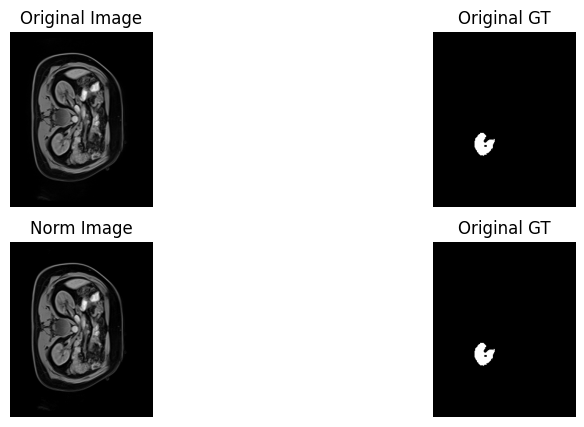

In [9]:
z_index = image_array.shape[2] // 2
fig, ax = plt.subplots(2, 2, figsize=(10, 5))
ax[0,0].imshow(image_array[:, :, z_index], cmap='gray')
ax[0,0].set_title('Original Image')
ax[0,0].axis('off')
ax[0,1].imshow(gt_array[:, :, z_index], cmap='gray')
ax[0,1].set_title('Original GT')
ax[0,1].axis('off')

z_index_resized = image_norm.shape[-1] // 2
ax[1,0].imshow(image_norm[:, :, z_index_resized], cmap='gray')
ax[1,0].set_title('Norm Image')
ax[1,0].axis('off')
ax[1,1].imshow(gt_array[:, :, z_index_resized], cmap='gray')
ax[1,1].set_title('Original GT')
ax[1,1].axis('off')

plt.show()